Import libraries

In [1]:
import numpy as np
import xarray as xr
import cf_xarray
from xgcm import Grid, generate_grid_ds
import gsw_xarray as gsw

import neutralocean
import neutralocean.grid.rectilinear
import neutralocean.ntp

from xgcm import Grid
import gsw_xarray as gsw

import matplotlib.pyplot as plt

import jax
from jax import numpy as jnp
import optax
import matplotlib.pyplot as plt

In [2]:
import neutral_density as nd

In [3]:
from importlib import reload

In [4]:
reload(nd)

<module 'neutral_density' from '/home/romain/Documents/work/2025-Jaxathon/neutral-density/src/neutral_density/__init__.py'>

In [5]:
ds = xr.open_dataset("dataset.nc")

In [6]:
ds = ds.isel(x_c=[-30], x_f=[-30])

## Create geometrical variables

* scale factors
* mask

In [7]:
e1u = jnp.array(ds.e1tu.broadcast_like(ds.t_an).transpose("x_c", "y_c", "z_c"))
e2v = jnp.array(ds.e2.broadcast_like(ds.t_an).transpose("x_c", "y_c", "z_c"))
e3w = jnp.array(ds.e3w.broadcast_like(ds.z_f+ds.x_c+ds.y_c).transpose("x_c", "y_c", "z_f"))

In [8]:
e123t = e1u * e2v * e3w
mask_water = 1 # only when we can compute derivatives ## TODO
tot_vol = (e123t*mask_water).sum()
weight_per_point = e123t / tot_vol

In [9]:
mask_T = jnp.isfinite(jnp.array(ds.cf["sea_water_temperature"])).astype(jnp.int32)

/tmp/ipykernel_1058244/2949225597.py:1: UserWarning: Variables {'crs', 'time'} not found in object but are referred to in the CF attributes.
  mask_T = jnp.isfinite(jnp.array(ds.cf["sea_water_temperature"])).astype(jnp.int32)


In [10]:
gradient_of_the_mask = nd.gradient_centered(mask_T, 0*mask_T+1, 0*mask_T+1, 0*mask_T+1)

In [11]:
mask_gradient = (gradient_of_the_mask==0) & (jnp.array([mask_T, mask_T, mask_T]))
mask_gradient = mask_gradient.at[2,:,:,0].set(0) # surface
mask_gradient = mask_gradient.at[2,:,:,-1].set(0) # last point
# Attention vertical component

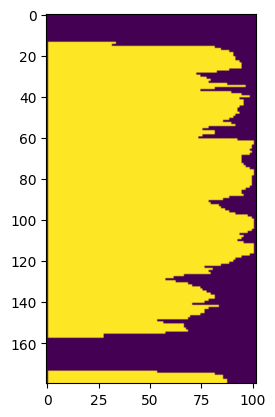

In [12]:
plt.imshow(mask_gradient[2][0])

In [13]:
mask_gradient.shape

(3, 1, 180, 102)

In [14]:
ds = ds.fillna(0.)

## Computing reference density gradient $\vec{A}$

$$
\vec{A'} = - \alpha \vec{\nabla} \Theta + \beta \vec{\nabla} S_A
$$

$$
\rho = \rho_0 (-\alpha (\Theta - \Theta_0))
$$


We use centred finite differences so everything is at the T points

In [15]:
dCT = nd.gradient_centered(jnp.array(ds.cf["sea_water_conservative_temperature"]), e1u, e2v, e3w)
dSA = nd.gradient_centered(jnp.array(ds.cf["sea_water_absolute_salinity"]), e1u, e2v, e3w)

In [16]:
# lin EOS in temperature only
# alpha = 2e-4 ## approx mean value of alpha
# beta = 0

In [17]:
alpha = 2e-4
beta = 0

In [18]:
A = 1026*(-alpha * dCT + beta * dSA) * mask_gradient

In [19]:
jnp.mean(A[2])

Array(0.00148581, dtype=float32)

## Solve the problem

In [20]:
gamma0 = jax.numpy.array(
    (1-(ds.cf["sea_water_conservative_temperature"].mean(
        ["x_c", "y_c"]
    ).broadcast_like(ds.cf["sea_water_conservative_temperature"]) - 10)
    * alpha) * 1026
)

In [21]:
gamma0.shape
initial_gamma = gamma0
initial_b = jnp.ones(initial_gamma.shape)
init_params = jnp.array([initial_gamma, initial_b])

In [22]:
nd.loss(
    gamma0, initial_b, A, e1u, e2v, e3w, weight_per_point, mask_gradient,
    normalization=jnp.array([1e5, 1e5, 1])[:, jnp.newaxis, jnp.newaxis, jnp.newaxis]
)

Array(1.07770706e-13, dtype=float32)

In [23]:
nd.loss_components(
    gamma0, initial_b, A, e1u, e2v, e3w, weight_per_point, mask_gradient,
    normalization=jnp.array([1e5, 1e5, 1])[:, jnp.newaxis, jnp.newaxis, jnp.newaxis]
)

Array([0.0000000e+00, 7.8474045e-14, 2.9296661e-14], dtype=float32)

In [24]:
#loss1_at_each_point = nd.loss1_at_each_point(
#    gamma0, initial_b, A, e1u, e2v, e3w, weight_per_point, mask_gradient,
#    normalization=jnp.array([1, 1, 1])[:, jnp.newaxis, jnp.newaxis, jnp.newaxis]
#)

In [25]:
#xr.DataArray(loss1_at_each_point[0,0].T).plot(yincrease=False, robust=True)

In [26]:
loss2_at_each_point = nd.loss2_at_each_point(
    gamma0, initial_b, A, e1u, e2v, e3w, weight_per_point, mask_gradient,
    normalization=jnp.array([1, 1, 1])[:, jnp.newaxis, jnp.newaxis, jnp.newaxis]
)

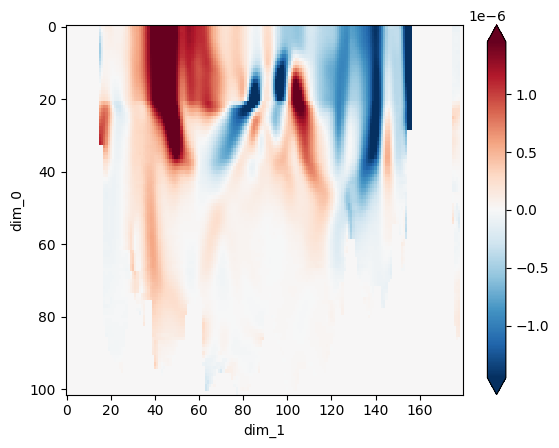

In [27]:
xr.DataArray(loss2_at_each_point[1,0].T).plot(yincrease=False, robust=True)

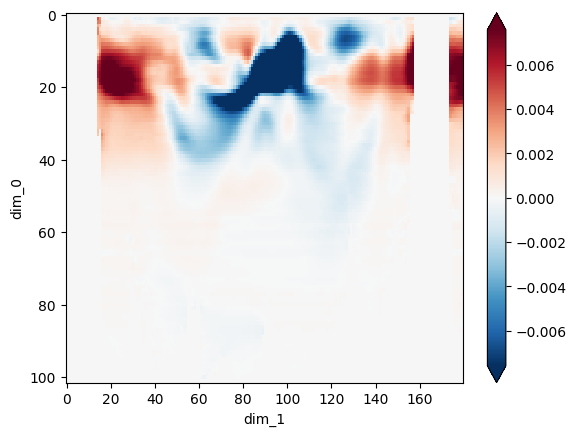

In [28]:
xr.DataArray(loss2_at_each_point[2,0].T).plot(yincrease=False, robust=True)

In the theoretical case of a linear EOS, we know that there exists a solution, and what it is. Normalizing the loss function should only play a role in the speed of minimization, and/or in the accuracy (due to numerical errors).

We can thus start the minimization problem

In [29]:
gamma1 = jax.numpy.array(
    (1-(ds.cf["sea_water_conservative_temperature"] - 10)
    * alpha) * 1026
)

In [30]:
omega1 = np.min(gamma1)
omega2 = np.max(gamma1)
print(omega1, omega2)

1022.3875 1028.4711


### Optimization of $\gamma$

In [31]:
initial_gamma = gamma0
initial_b = jnp.ones(initial_gamma.shape)
init_params = jnp.array([initial_gamma, initial_b])

In [32]:
#floss = lambda gamma: nd.loss(nd.tilde_m1(gamma, omega1, omega2), A, e1u, e2v, e3w, weight_per_point, mask_gradient,
#    normalization=jnp.array([1e10, 1e10, 1e10])[:, jnp.newaxis, jnp.newaxis, jnp.newaxis])

In [33]:
floss = lambda gamma: 1e15*nd.loss(gamma, A, e1u, e2v, e3w, weight_per_point, mask_gradient,
    normalization=jnp.array([1, 1, 1])[:, jnp.newaxis, jnp.newaxis, jnp.newaxis])

In [34]:
floss = lambda gamma_and_b: 1e25*nd.loss(gamma_and_b[0], gamma_and_b[1], A, e1u, e2v, e3w, weight_per_point, mask_gradient,
    normalization=jnp.array([1, 1, 1])[:, jnp.newaxis, jnp.newaxis, jnp.newaxis])

In [35]:
grad_loss = jax.grad(floss)

def train(params, learning_rate=0.01, num_steps=1000):
    """Train using gradient descent optimization"""
    # Define optimizer
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(params)
    
    losses = []
    
    for step in range(num_steps):
        # Compute loss and gradients
        loss = floss(params)
        #grads = jnp.nan_to_num(grad_loss(params))
        grads = grad_loss(params)
        
        losses.append(loss)
        
        # Apply updates
        updates, opt_state = optimizer.update(grads, opt_state)
        params = nd.tilde_m1(optax.apply_updates(params, updates), omega1, omega2)
        
        # Print progress every 100 steps
        if step % 100 == 0:
            print(f"Step {step}, Loss: {loss}")
            xr.DataArray(params[0,:,:].T).where(xr.DataArray(mask_gradient[0,0].T)==1).plot(yincrease=False)
            plt.show()
    
    return params, losses

In [36]:
opt = optax.lbfgs()

def run_opt(init_params, fun, opt, max_iter, tol):
  value_and_grad_fun = optax.value_and_grad_from_state(fun)

  def step(carry):
    params, state = carry
    value, grad = value_and_grad_fun(params, state=state)
    updates, state = opt.update(
        grad, state, params, value=value, grad=grad, value_fn=fun
    )
    params = optax.apply_updates(params, updates)
    return params, state

  def continuing_criterion(carry):
    _, state = carry
    iter_num = optax.tree.get(state, 'count')
    grad = optax.tree.get(state, 'grad')
    err = optax.tree.norm(grad)
    return (iter_num == 0) | ((iter_num < max_iter) & (err >= tol))

  init_carry = (init_params, opt.init(init_params))
  final_params, final_state = jax.lax.while_loop(
      continuing_criterion, step, init_carry
  )
  return final_params, final_state

In [50]:

fun = floss
print(
    f'Initial value: {fun(init_params):.2e} '
    f'Initial gradient norm: {optax.tree.norm(jax.grad(fun)(init_params)):.2e}'
)
final_params, _ = run_opt(init_params, fun, opt, max_iter=10000, tol=1e-5)
print(
    f'Final value: {fun(final_params):.2e}, '
    f'Final gradient norm: {optax.tree.norm(jax.grad(fun)(final_params)):.2e}'
)

Initial value: 1.08e+12 Initial gradient norm: 8.67e+10
Final value: 1.82e+08, Final gradient norm: 2.28e+08


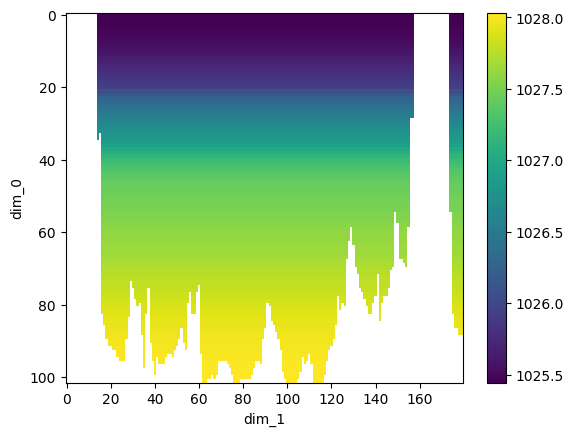

In [51]:
xr.DataArray(gamma0.T).where(xr.DataArray(mask_gradient[0,0].T)==1).plot(yincrease=False)

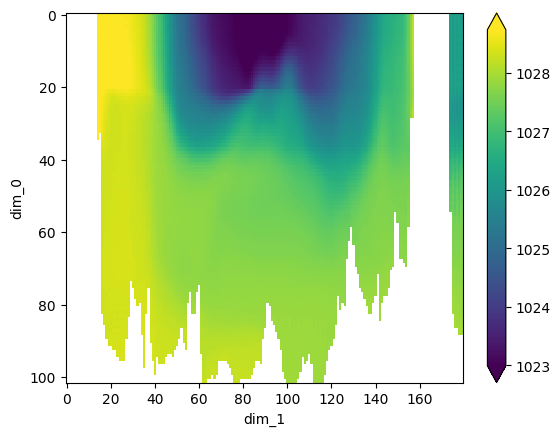

In [52]:
xr.DataArray(final_params[0].T).where(xr.DataArray(mask_gradient[0,0].T)==1).plot(yincrease=False, robust=True)

In [47]:
nd.loss_components(
    gamma0, initial_b, A, e1u, e2v, e3w, weight_per_point, mask_gradient,
    normalization=jnp.array([1e5, 1e5, 1])[:, jnp.newaxis, jnp.newaxis, jnp.newaxis]
)

Array([0.0000000e+00, 7.8474045e-14, 2.9296661e-14], dtype=float32)

In [48]:
nd.loss_components(
    final_params[0], final_params[1], A, e1u, e2v, e3w, weight_per_point, mask_gradient,
    normalization=jnp.array([1e5, 1e5, 1])[:, jnp.newaxis, jnp.newaxis, jnp.newaxis]
)

Array([0.0000000e+00, 8.6555962e-19, 1.8475676e-17], dtype=float32)

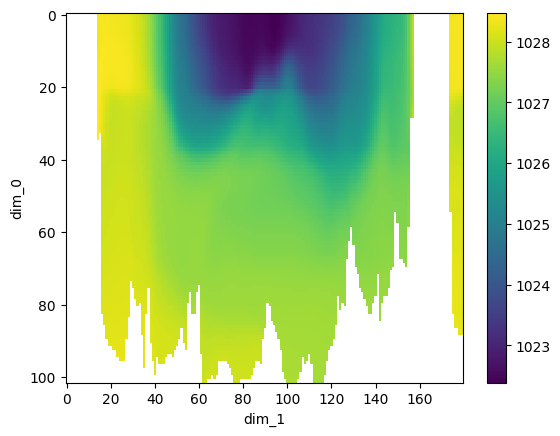

In [49]:
xr.DataArray(gamma1.T).where(xr.DataArray(mask_gradient[0,0].T)==1).plot(yincrease=False)

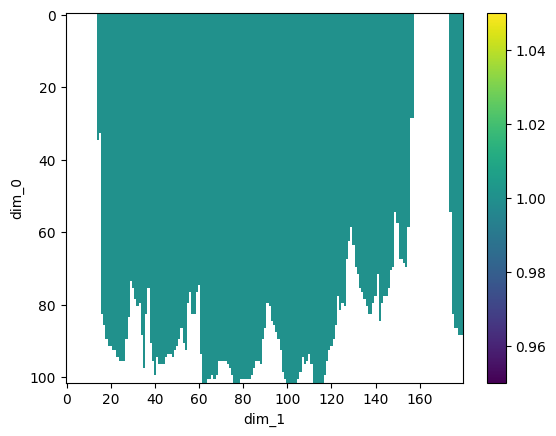

In [43]:
xr.DataArray(final_params[1].T).where(xr.DataArray(mask_gradient[0,0].T)==1).plot(yincrease=False, robust=True)

In [ ]:
xr.plot.

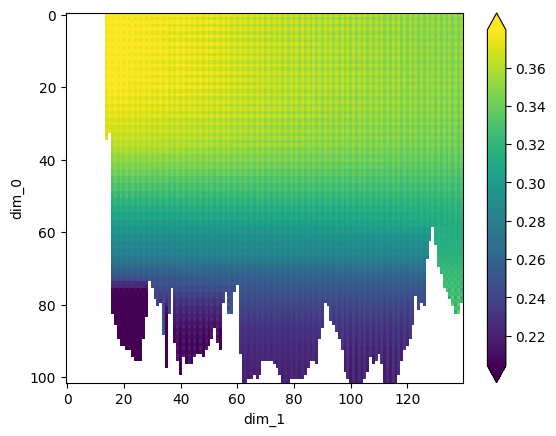

In [58]:
xr.DataArray((final_params[0].T-gamma1.T)[:,:140]).where(
    xr.DataArray(mask_gradient[0,0].T)[:,:140]==1
).plot(
    yincrease=False, robust=True
)